# UMAP Analysis of 52D Interpretable Embedding Space

Analysis of the **Mean-only 52D** track-level embedding on GTZAN.

Sections:
1. Data loading & preprocessing
2. HDBSCAN Clustering (52D)
3. UMAP Projection & Genre analysis
4. UMAP by individual features
5. UMAP by feature blocks (PCA → 1D)
6. Inter-genre distance matrix

In [1]:
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import umap
import hdbscan
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Project imports
sys.path.insert(0, str(Path('.').resolve().parent))
from src.interpretable_embeddings import compute_bar_embeddings, feature_names

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

PLOTS_DIR = Path('..') / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


## 1. Data Loading & 52D Mean Embedding


In [2]:
GTZAN_DIR = Path('..') / 'data' / 'genres_30sec'

all_bar_data = []  # list of (n_bars, 52) arrays
labels = []
filenames = []

genres = sorted([d.name for d in GTZAN_DIR.iterdir()
                 if d.is_dir() and not d.name.startswith('.')])
print(f"Found {len(genres)} genres: {genres}")

for genre in tqdm(genres, desc="Processing genres"):
    genre_dir = GTZAN_DIR / genre
    audio_files = sorted(genre_dir.glob("*.*"))[:100]
    count = 0
    for af in tqdm(audio_files, desc=f"  {genre}", leave=False):
        if af.suffix.lower() not in ('.wav', '.mp3', '.flac', '.au', '.ogg'):
            continue
        try:
            bar_emb = compute_bar_embeddings(str(af))
            if bar_emb.shape[0] == 0:
                continue
            all_bar_data.append(bar_emb)
            labels.append(genre)
            filenames.append(af.name)
            count += 1
        except Exception as e:
            print(f"  ⚠ Error processing {af.name}: {e}")

print(f"\nTotal: {len(all_bar_data)} tracks")

# Build 52D mean embedding
X_52d = np.array([b.mean(axis=0) for b in all_bar_data])
genres_arr = np.array(labels)
fnames = feature_names()

# Scale for analysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_52d)

print(f"X_52d shape: {X_52d.shape}")

Found 10 genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


Processing genres:   0%|          | 0/10 [00:00<?, ?it/s]

  blues:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  classical:   0%|          | 0/100 [00:00<?, ?it/s]

...

  metal:   0%|          | 0/100 [00:00<?, ?it/s]

  pop:   0%|          | 0/100 [00:00<?, ?it/s]

  reggae:   0%|          | 0/100 [00:00<?, ?it/s]

  rock:   0%|          | 0/100 [00:00<?, ?it/s]


Total: 999 tracks
X_52d shape: (999, 52)


## 2. HDBSCAN Clustering (52D)

Unsupervised clustering *directly* in the 52D space (before UMAP distortion).

In [3]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
)
hdb_labels = clusterer.fit_predict(X_scaled)

n_clusters = hdb_labels.max() + 1
n_noise = (hdb_labels == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} / {len(hdb_labels)}")

# Metrics vs ground truth
valid = hdb_labels >= 0
ari = adjusted_rand_score(genres_arr[valid], hdb_labels[valid])
nmi = normalized_mutual_info_score(genres_arr[valid], hdb_labels[valid])
print(f"ARI vs Genres: {ari:.3f}")
print(f"NMI vs Genres: {nmi:.3f}")

Clusters found: 2
Noise points: 844 / 999
ARI vs Genres: 0.092
NMI vs Genres: 0.186


In [4]:
def interpret_cluster(z_scores, feat_names):
    name_to_idx = {n: i for i, n in enumerate(feat_names)}
    descriptions = []
    checks = [
        ('dft_mag_diatonicity', 0.5, "strongly diatonic", "chromatic/atonal"),
        ('tonal_stability', 0.5, "clear tonal center", "tonally ambiguous"),
        ('spectral_centroid', 0.5, "bright timbre", "dark timbre"),
        ('spectral_flatness', 0.5, "noisy/percussive", "tonal/pitched"),
        ('onset_strength_mean', 0.5, "rhythmically dense", "sparse/legato"),
        ('log_rms', 0.5, "loud", "quiet"),
        ('sensory_dissonance', 0.5, "dissonant", "consonant"),
    ]
    for feat, thresh, high_desc, low_desc in checks:
        if feat in name_to_idx:
            z = z_scores[name_to_idx[feat]]
            if z > thresh: descriptions.append(high_desc)
            elif z < -thresh: descriptions.append(low_desc)
    return ", ".join(descriptions) if descriptions else "No strong features"

global_mean = X_scaled.mean(axis=0)
global_std = X_scaled.std(axis=0) + 1e-9

for cl in range(n_clusters):
    mask = hdb_labels == cl
    n_points = mask.sum()
    cl_genres = genres_arr[mask]
    genre_counts = {}
    for g in cl_genres: genre_counts[g] = genre_counts.get(g, 0) + 1
    top_genres = sorted(genre_counts.items(), key=lambda x: -x[1])[:3]
    genre_str = ', '.join(f"{g}({c})" for g, c in top_genres)
    cl_mean = X_scaled[mask].mean(axis=0)
    z = (cl_mean - global_mean) / global_std
    top_high = np.argsort(z)[-5:][::-1]
    print(f"\nCluster {cl} ({n_points} tracks) | Genres: {genre_str}")
    print(f"  → Interpretation: {interpret_cluster(z, fnames)}")
    print(f"  High z-scores: {[fnames[idx] for idx in top_high if z[idx]>0.3]}")


Cluster 0 (44 tracks) | Genres: disco(14), pop(14), jazz(6)
  → Interpretation: chromatic/atonal, bright timbre
  High z-scores: ['spectral_bandwidth', 'mfcc_6', 'mfcc_8', 'mfcc_10', 'mfcc_0']

Cluster 1 (111 tracks) | Genres: metal(40), disco(25), rock(11)
  → Interpretation: chromatic/atonal
  High z-scores: ['mfcc_9', 'mfcc_11', 'mfcc_7', 'mfcc_5', 'mfcc_3']


## 3. UMAP Projection & Visual Analysis

2D UMAP projection and scatter plots by genre/cluster.

In [5]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    verbose=True,
)
X_2d = reducer.fit_transform(X_scaled)

UMAP(n_jobs=1, random_state=42, verbose=True)
Mon Mar  2 23:23:06 2026 Construct fuzzy simplicial set


/Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Mar  2 23:23:07 2026 Finding Nearest Neighbors
Mon Mar  2 23:23:09 2026 Finished Nearest Neighbor Search
Mon Mar  2 23:23:10 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Mar  2 23:23:12 2026 Finished embedding


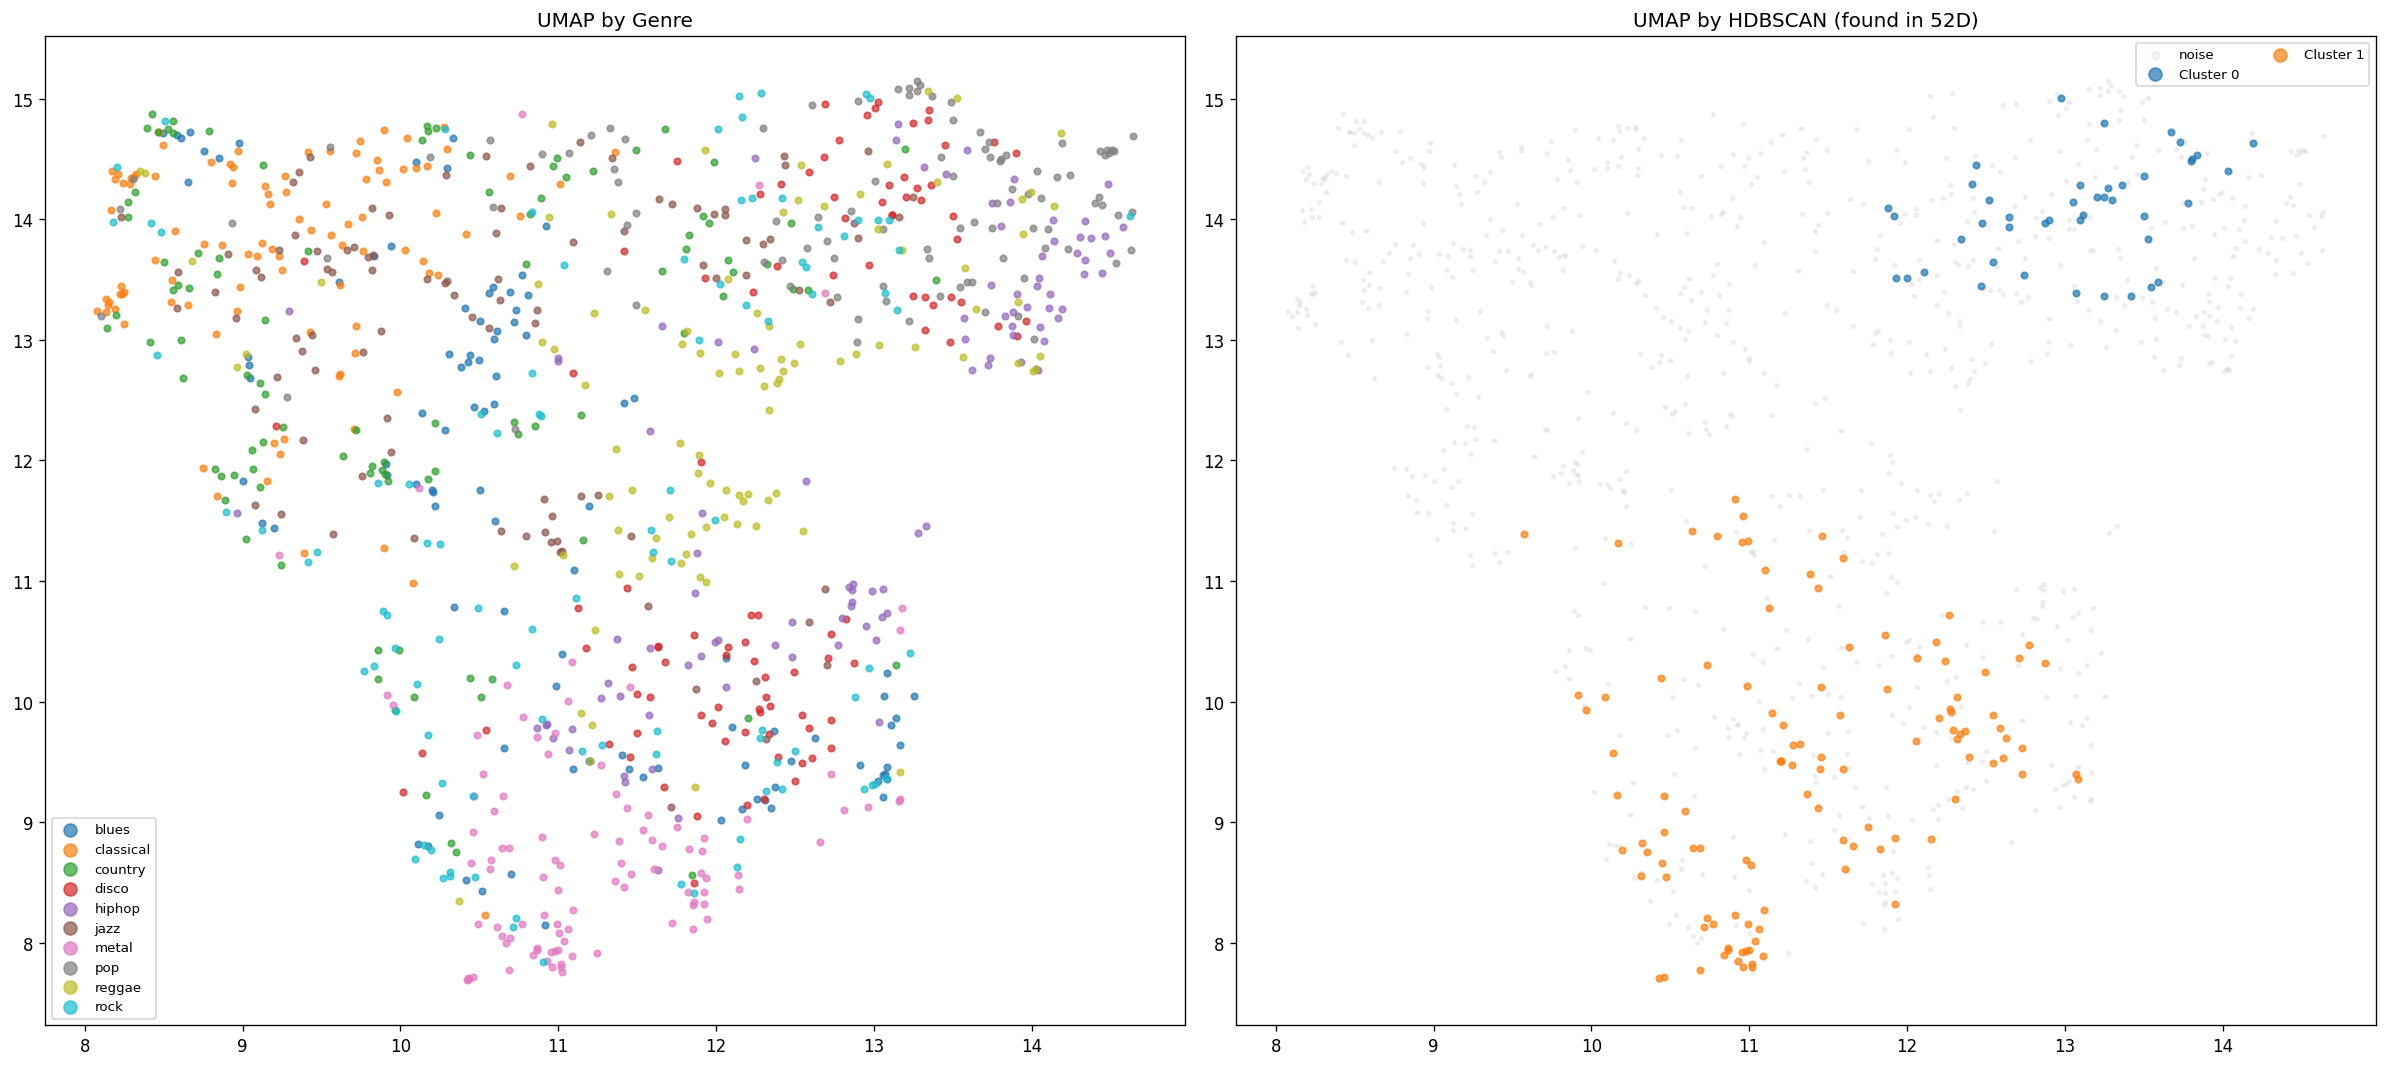

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
unique_genres = np.unique(genres_arr)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_genres)))

# Left: Genres
for genre, color in zip(unique_genres, colors):
    mask = genres_arr == genre
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], label=genre, s=15, alpha=0.7)
axes[0].set_title('UMAP by Genre')
axes[0].legend(fontsize=8, markerscale=2)

# Right: HDBSCAN Clusters
noise_mask = hdb_labels == -1
axes[1].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='lightgray', s=5, alpha=0.3, label='noise')
for cl in range(n_clusters):
    mask = hdb_labels == cl
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=15, alpha=0.7, label=f'Cluster {cl}')
axes[1].set_title('UMAP by HDBSCAN (found in 52D)')
axes[1].legend(fontsize=8, markerscale=2, ncol=2)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'umap_visualization.png')
plt.show()

## 4. UMAP Colored by Individual Features


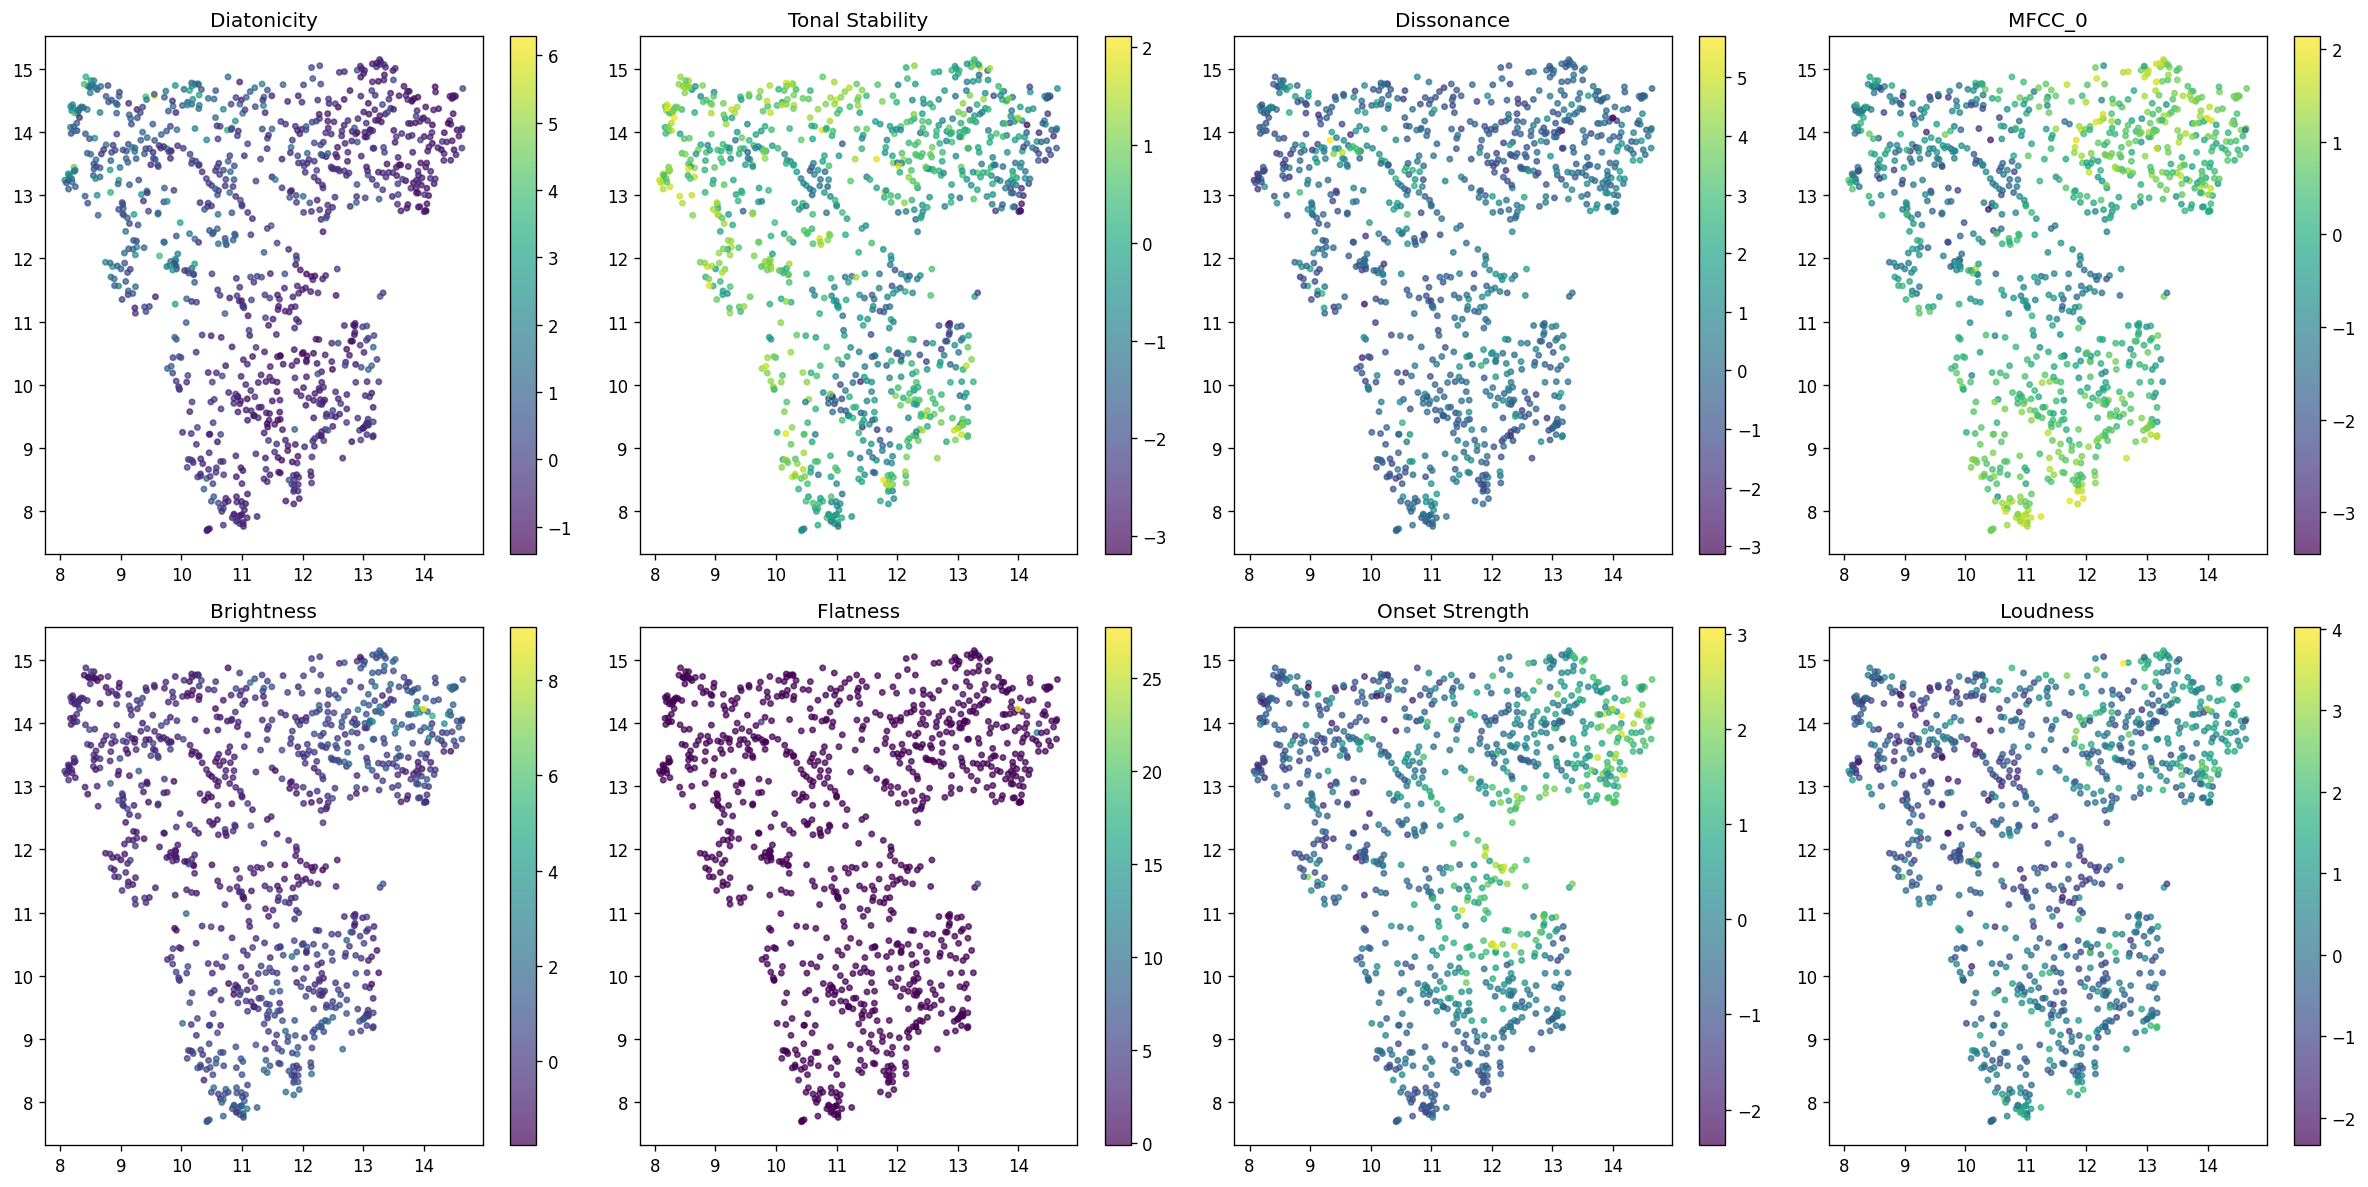

In [7]:
name_to_idx = {n: i for i, n in enumerate(fnames)}
interesting = {
    'dft_mag_diatonicity': 'Diatonicity', 'tonal_stability': 'Tonal Stability',
    'sensory_dissonance': 'Dissonance', 'mfcc_0': 'MFCC_0',
    'spectral_centroid': 'Brightness', 'spectral_flatness': 'Flatness',
    'onset_strength_mean': 'Onset Strength', 'log_rms': 'Loudness',
}
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (feat_name, title) in zip(axes.flat, interesting.items()):
    idx = name_to_idx[feat_name]
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=X_scaled[:, idx], cmap='viridis', s=10, alpha=0.7)
    ax.set_title(title); plt.colorbar(scatter, ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'umap_feature_coloring.png')
plt.show()

## 5. UMAP Colored by Feature Blocks (PCA → 1D)


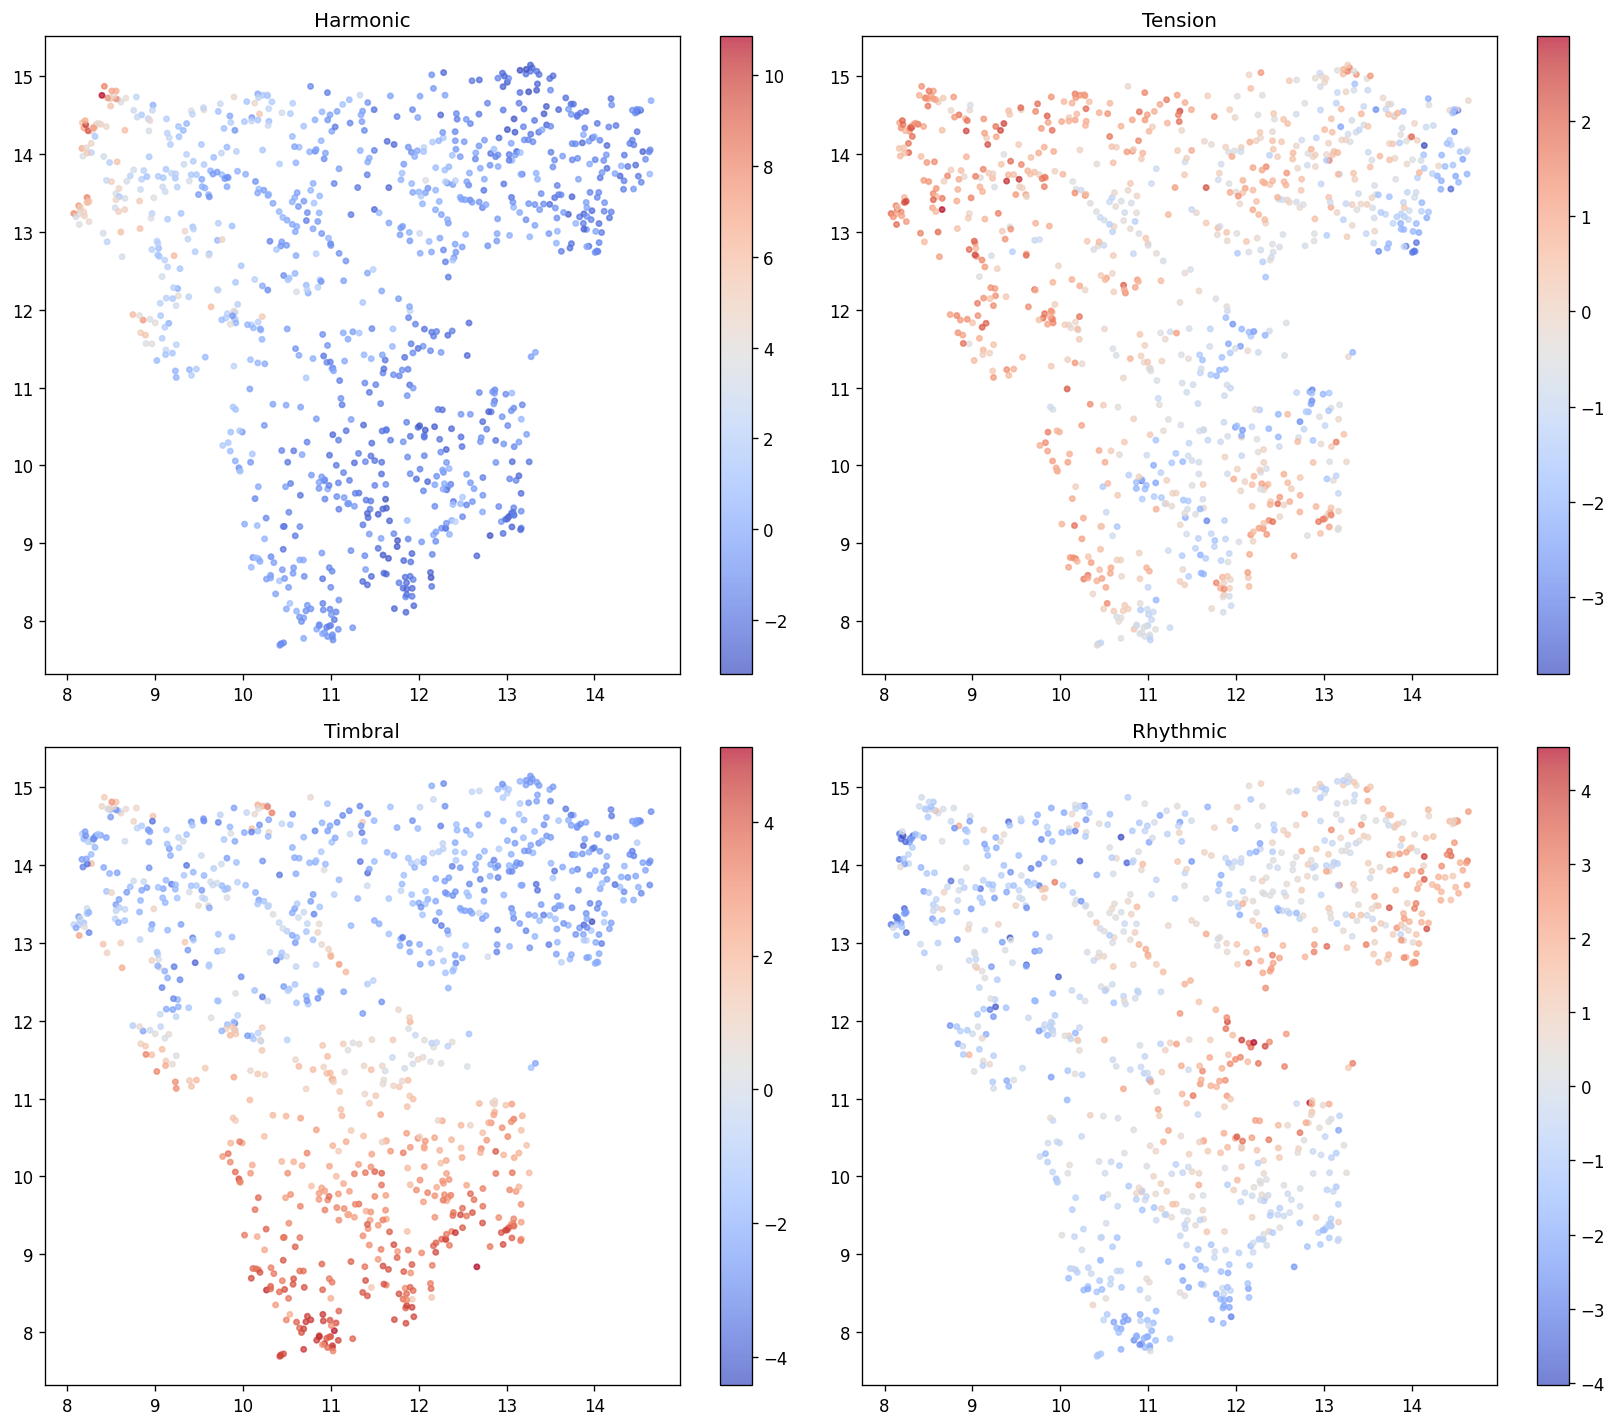

In [8]:
blocks = {
    'Harmonic': list(range(0, 28)), 'Tension': [28, 29, 30],
    'Timbral': list(range(31, 47)), 'Rhythmic': [49, 50, 51],
}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (block_name, indices) in zip(axes.flat, blocks.items()):
    pca_1d = PCA(n_components=1).fit_transform(X_scaled[:, indices]).ravel()
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=pca_1d, cmap='coolwarm', s=10, alpha=0.7)
    ax.set_title(block_name); plt.colorbar(scatter, ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'umap_block_projection.png')
plt.show()

## 6. Inter-genre Distance Matrix


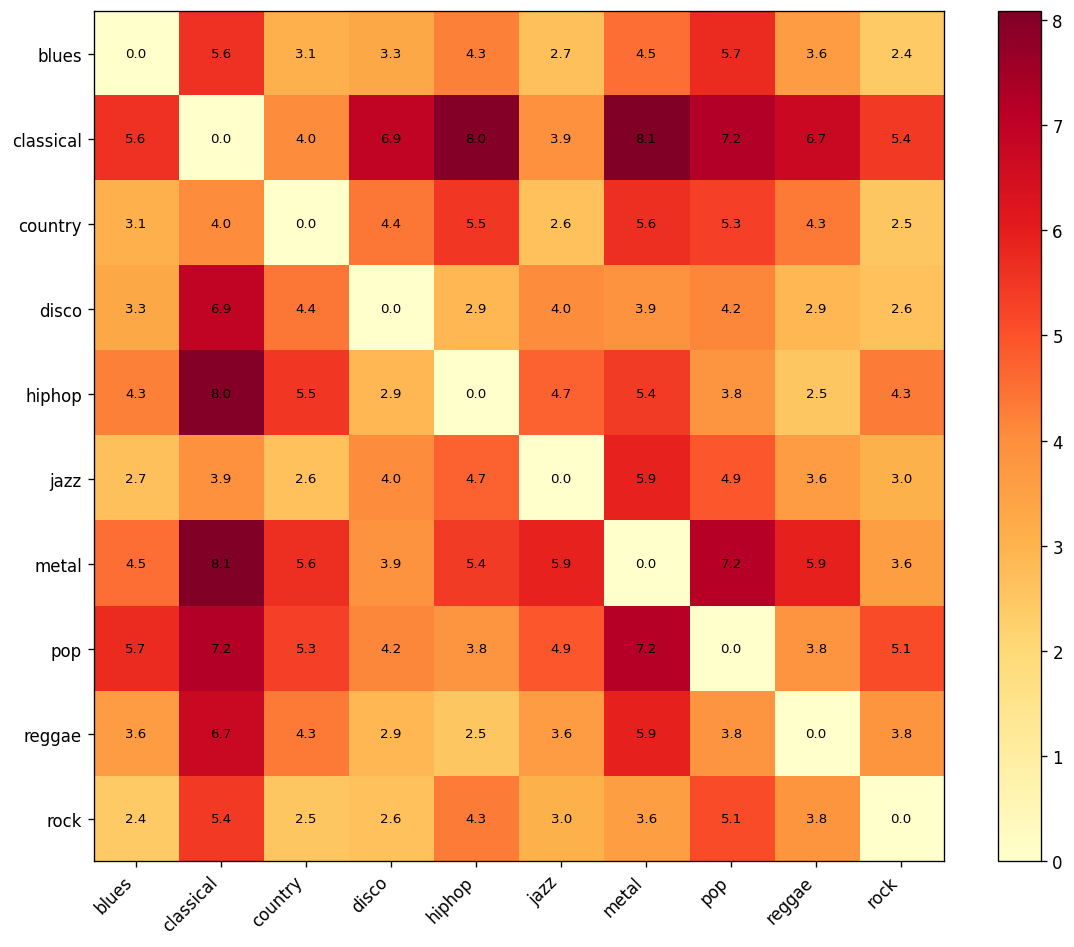

In [9]:
unique_genres_sorted = sorted(np.unique(genres_arr))
centroids = {g: X_scaled[genres_arr == g].mean(axis=0) for g in unique_genres_sorted}
dist_matrix = np.zeros((len(unique_genres_sorted), len(unique_genres_sorted)))
for i, g1 in enumerate(unique_genres_sorted):
    for j, g2 in enumerate(unique_genres_sorted):
        dist_matrix[i, j] = np.linalg.norm(centroids[g1] - centroids[g2])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dist_matrix, cmap='YlOrRd')
ax.set_xticks(range(len(unique_genres_sorted))); ax.set_xticklabels(unique_genres_sorted, rotation=45, ha='right')
ax.set_yticks(range(len(unique_genres_sorted))); ax.set_yticklabels(unique_genres_sorted)
for i in range(len(unique_genres_sorted)):
    for j in range(len(unique_genres_sorted)):
        ax.text(j, i, f'{dist_matrix[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'genre_distance_matrix.png')
plt.show()